# Dataset Analysis — Skin Type Classifier

This notebook performs a comprehensive analysis of the three datasets used for Fitzpatrick Skin Type (FST) classification:

1. **SCIN** — Self-reported skin conditions from Google Health
2. **PAD-UFES-20** — Clinical dermatology images from Brazil
3. **Fitzpatrick 17k** — Web-sourced dermatology images with expert FST annotations

The analysis covers dataset composition, class distributions, demographics, diagnosis conditions, and pixel-level image properties to inform preprocessing and training decisions.

## 1. Setup & Data Loading

In [2]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageStat
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 16,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.1,
    }
)
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_COLORS = {"scin": "#4C72B0", "pad_ufes": "#DD8452", "fitzpatrick_17k": "#55A868"}
DATASET_LABELS = {"scin": "SCIN", "pad_ufes": "PAD-UFES-20", "fitzpatrick_17k": "Fitzpatrick 17k"}
SOURCE_KEYS = ["scin", "pad_ufes", "fitzpatrick_17k"]
FST_COLORS = {1: "#F5D6BA", 2: "#E8C39E", 3: "#D4A574", 4: "#A67C52", 5: "#7A5230", 6: "#4A2912"}
FST_LABELS = {i: f"FST {i}" for i in range(1, 7)}

In [3]:
df = pd.read_csv(DATA_DIR / "full_dataset.csv")

df_scin = pd.read_csv(DATA_DIR / "scin" / "cleaned_scin_metadata.csv")
df_pad = pd.read_csv(DATA_DIR / "pad_ufes" / "cleaned_pad_ufes_metadata.csv")
df_fitz = pd.read_csv(DATA_DIR / "fitzpatrick_17k" / "cleaned_fitzpatrick_17k_metadata.csv")

df_missing_scin = pd.read_csv(DATA_DIR / "scin" / "missing_fitzpatrick_labels_scin.csv")
df_missing_pad = pd.read_csv(DATA_DIR / "pad_ufes" / "missing_fitzpatrick_labels_pad_ufes.csv")
df_missing_fitz = pd.read_csv(DATA_DIR / "fitzpatrick_17k" / "missing_fitzpatrick_labels_fitzpatrick_17k.csv")
df_wrong_fitz = pd.read_csv(DATA_DIR / "fitzpatrick_17k" / "wrong_entries_fitzpatrick_17k.csv")

print(f"Unified dataset: {len(df):,} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print("\nPer-dataset shapes:")
print(f"  SCIN:            {df_scin.shape[0]:,} cases, {df_scin.shape[1]} columns")
print(f"  PAD-UFES-20:     {df_pad.shape[0]:,} rows, {df_pad.shape[1]} columns")
print(f"  Fitzpatrick 17k: {df_fitz.shape[0]:,} rows, {df_fitz.shape[1]} columns")
print("\nUnified dataset source distribution:")
print(df["source"].value_counts().to_string())
print("\nMissing values in unified dataset:")
print(df.isna().sum().to_string())

Unified dataset: 19,291 rows, 6 columns
Columns: ['image_path', 'source', 'fitzpatrick_skin_type', 'diagnosis', 'age', 'sex']

Per-dataset shapes:
  SCIN:            4,364 cases, 73 columns
  PAD-UFES-20:     1,494 rows, 26 columns
  Fitzpatrick 17k: 8,740 rows, 15 columns

Unified dataset source distribution:
source
scin               9057
fitzpatrick_17k    8740
pad_ufes           1494

Missing values in unified dataset:
image_path                  0
source                      0
fitzpatrick_skin_type       0
diagnosis                   0
age                      8741
sex                      8741


## 2. Dataset Composition Overview

In [4]:
n_images_scin = len(list((DATA_DIR / "scin" / "scin_images").glob("*.png")))
n_images_pad = len(list((DATA_DIR / "pad_ufes" / "images").glob("*.png")))
n_images_fitz = len(list((DATA_DIR / "fitzpatrick_17k" / "images").glob("*.jpg")))

source_counts = df["source"].value_counts()
fst_ranges = df.groupby("source")["fitzpatrick_skin_type"].agg(["min", "max"])

summary_data = {
    "Dataset": ["SCIN", "PAD-UFES-20", "Fitzpatrick 17k", "Total"],
    "Images on disk": [n_images_scin, n_images_pad, n_images_fitz, n_images_scin + n_images_pad + n_images_fitz],
    "Rows in unified CSV": [
        source_counts.get("scin", 0),
        source_counts.get("pad_ufes", 0),
        source_counts.get("fitzpatrick_17k", 0),
        len(df),
    ],
    "Image format": [".png", ".png", ".jpg", "mixed"],
    "FST range": [
        f"{fst_ranges.loc['scin', 'min']}\u2013{fst_ranges.loc['scin', 'max']}",
        f"{fst_ranges.loc['pad_ufes', 'min']}\u2013{fst_ranges.loc['pad_ufes', 'max']}",
        f"{fst_ranges.loc['fitzpatrick_17k', 'min']}\u2013{fst_ranges.loc['fitzpatrick_17k', 'max']}",
        "1\u20136",
    ],
    "Age available": ["Partial (groups)", "Yes (integer)", "No", "\u2014"],
    "Sex available": ["Partial", "Yes", "No", "\u2014"],
}
display(pd.DataFrame(summary_data).style.hide(axis="index"))

Dataset,Images on disk,Rows in unified CSV,Image format,FST range,Age available,Sex available
SCIN,9057,9057,.png,1–6,Partial (groups),Partial
PAD-UFES-20,1494,1494,.png,1–6,Yes (integer),Yes
Fitzpatrick 17k,8740,8740,.jpg,1–6,No,No
Total,19291,19291,mixed,1–6,—,—


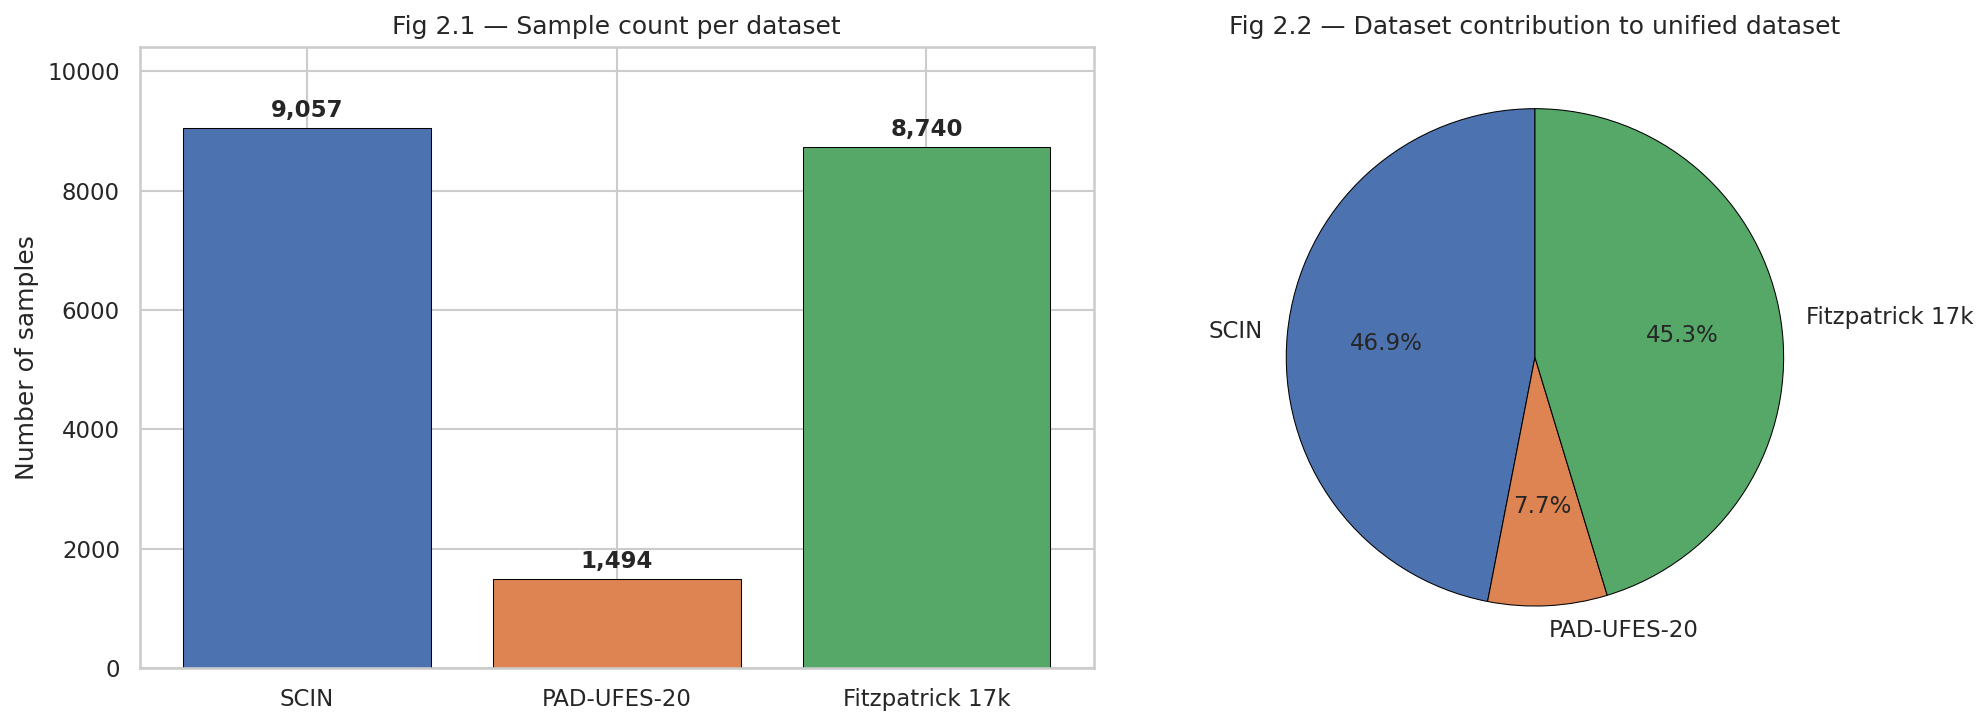

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = ["SCIN", "PAD-UFES-20", "Fitzpatrick 17k"]
counts = [source_counts.get(k, 0) for k in SOURCE_KEYS]
colors = [DATASET_COLORS[k] for k in SOURCE_KEYS]

bars = axes[0].bar(datasets, counts, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Fig 2.1 \u2014 Sample count per dataset")
for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
axes[0].set_ylim(0, max(counts) * 1.15)

axes[1].pie(
    counts,
    labels=datasets,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "black", "linewidth": 0.5},
)
axes[1].set_title("Fig 2.2 \u2014 Dataset contribution to unified dataset")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_2_1_2_dataset_composition.png")
plt.show()

,Dataset,Original samples,Excluded (missing FST / errors),Retained,Retention rate (%)
0,SCIN,10382,1325,9057,87.2
1,PAD-UFES-20,2298,804,1494,65.0
2,Fitzpatrick 17k,11394,2654,8740,76.7


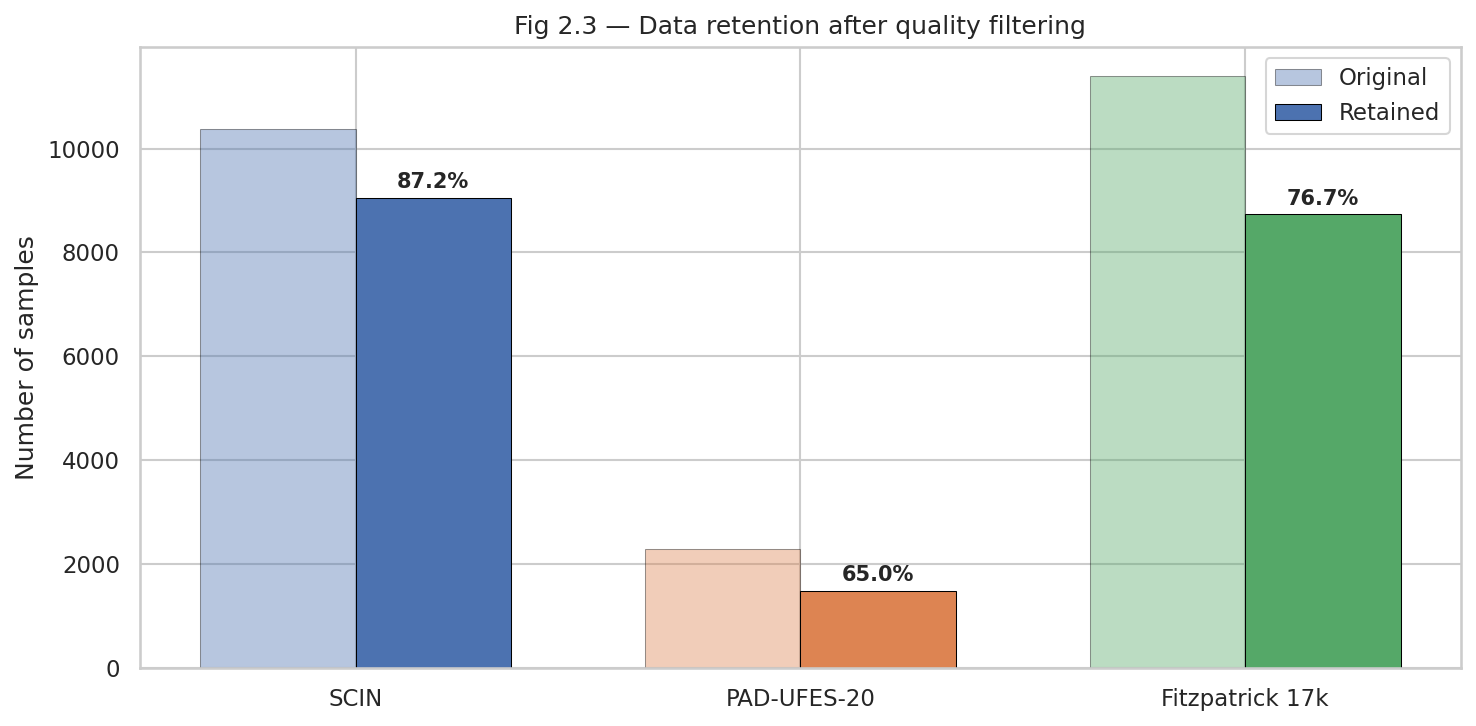

In [6]:
scin_missing_images = df_missing_scin[["image_1_path", "image_2_path", "image_3_path"]].notna().sum().sum()
scin_total_original = n_images_scin + scin_missing_images
pad_missing = len(df_missing_pad)
pad_total_original = len(df_pad) + pad_missing
fitz_wrong = len(df_wrong_fitz)
fitz_total_original = len(df_fitz) + fitz_wrong

exclusion_df = pd.DataFrame(
    {
        "Dataset": datasets,
        "Original samples": [scin_total_original, pad_total_original, fitz_total_original],
        "Excluded (missing FST / errors)": [scin_missing_images, pad_missing, fitz_wrong],
        "Retained": [n_images_scin, len(df_pad), len(df_fitz)],
    }
)
exclusion_df["Retention rate (%)"] = (exclusion_df["Retained"] / exclusion_df["Original samples"] * 100).round(1)
display(exclusion_df)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(exclusion_df))
width = 0.35
ax.bar(
    x - width / 2,
    exclusion_df["Original samples"],
    width,
    label="Original",
    color=colors,
    alpha=0.4,
    edgecolor="black",
    linewidth=0.5,
)
ax.bar(x + width / 2, exclusion_df["Retained"], width, label="Retained", color=colors, edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("Number of samples")
ax.set_title("Fig 2.3 \u2014 Data retention after quality filtering")
ax.legend()
for i, rate in enumerate(exclusion_df["Retention rate (%)"]):
    ax.text(
        x[i] + width / 2,
        exclusion_df["Retained"].iloc[i] + 100,
        f"{rate}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_2_3_data_retention.png")
plt.show()

## 3. Target Variable \u2014 Fitzpatrick Skin Type Distribution

The Fitzpatrick Skin Type (FST) scale classifies skin into 6 types based on response to UV exposure, ranging from very light (FST I) to very dark (FST VI). Understanding the class distribution is critical for designing the training strategy.

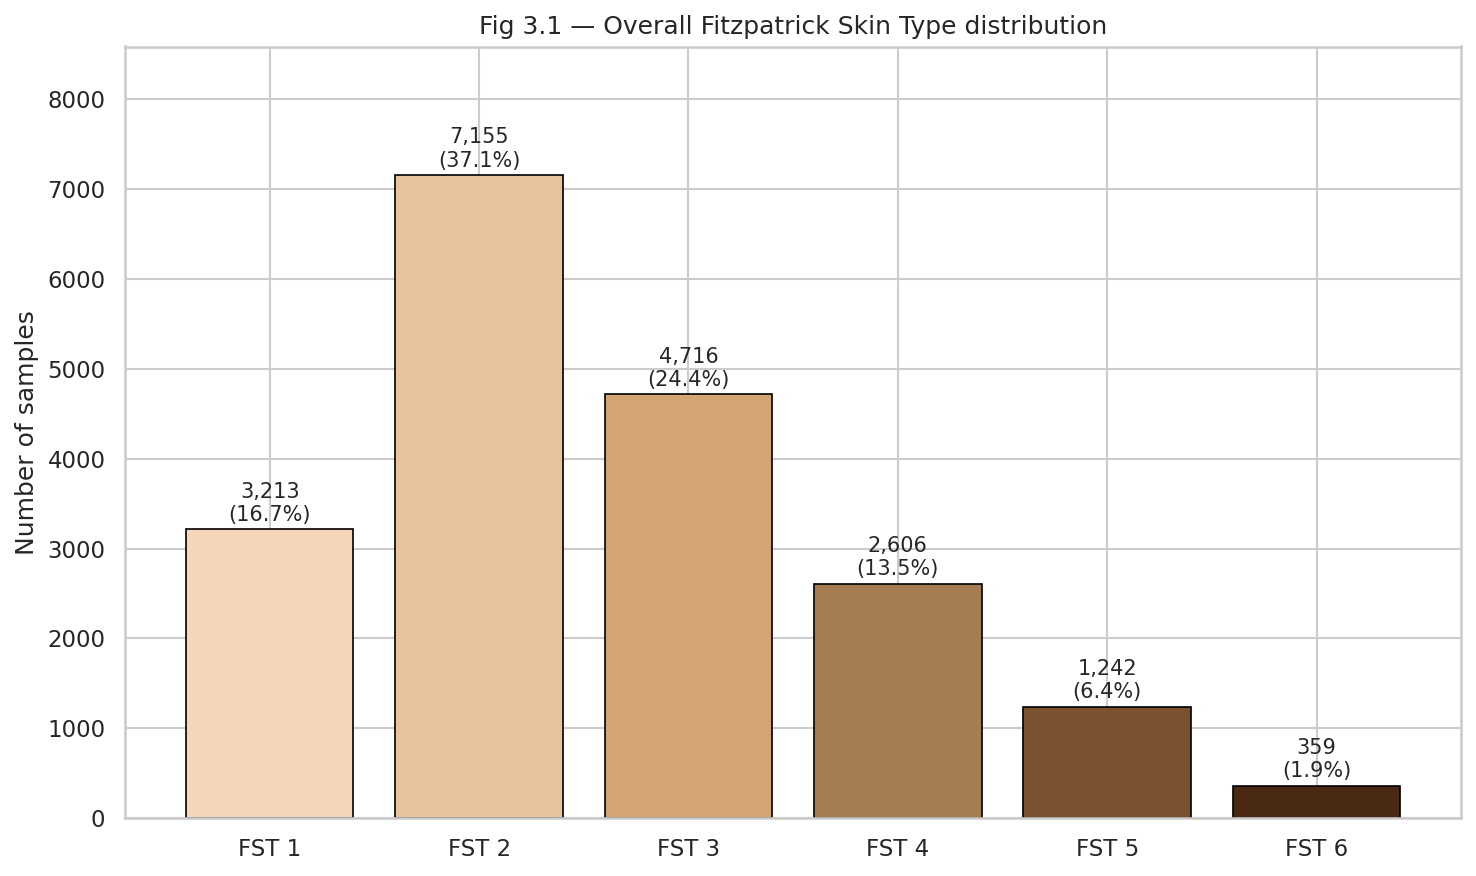

Class imbalance ratio (majority:minority): 7,155:359 = 19.9:1


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
fst_counts = df["fitzpatrick_skin_type"].value_counts().sort_index()
fst_colors_list = [FST_COLORS[i] for i in fst_counts.index]

bars = ax.bar(
    [FST_LABELS[i] for i in fst_counts.index],
    fst_counts.values,
    color=fst_colors_list,
    edgecolor="black",
    linewidth=0.8,
)
for bar, count in zip(bars, fst_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}\n({count / len(df) * 100:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylabel("Number of samples")
ax.set_title("Fig 3.1 \u2014 Overall Fitzpatrick Skin Type distribution")
ax.set_ylim(0, fst_counts.max() * 1.2)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_3_1_fst_distribution.png")
plt.show()

print(
    f"Class imbalance ratio (majority:minority): {fst_counts.max():,}:{fst_counts.min():,} = {fst_counts.max() / fst_counts.min():.1f}:1"
)

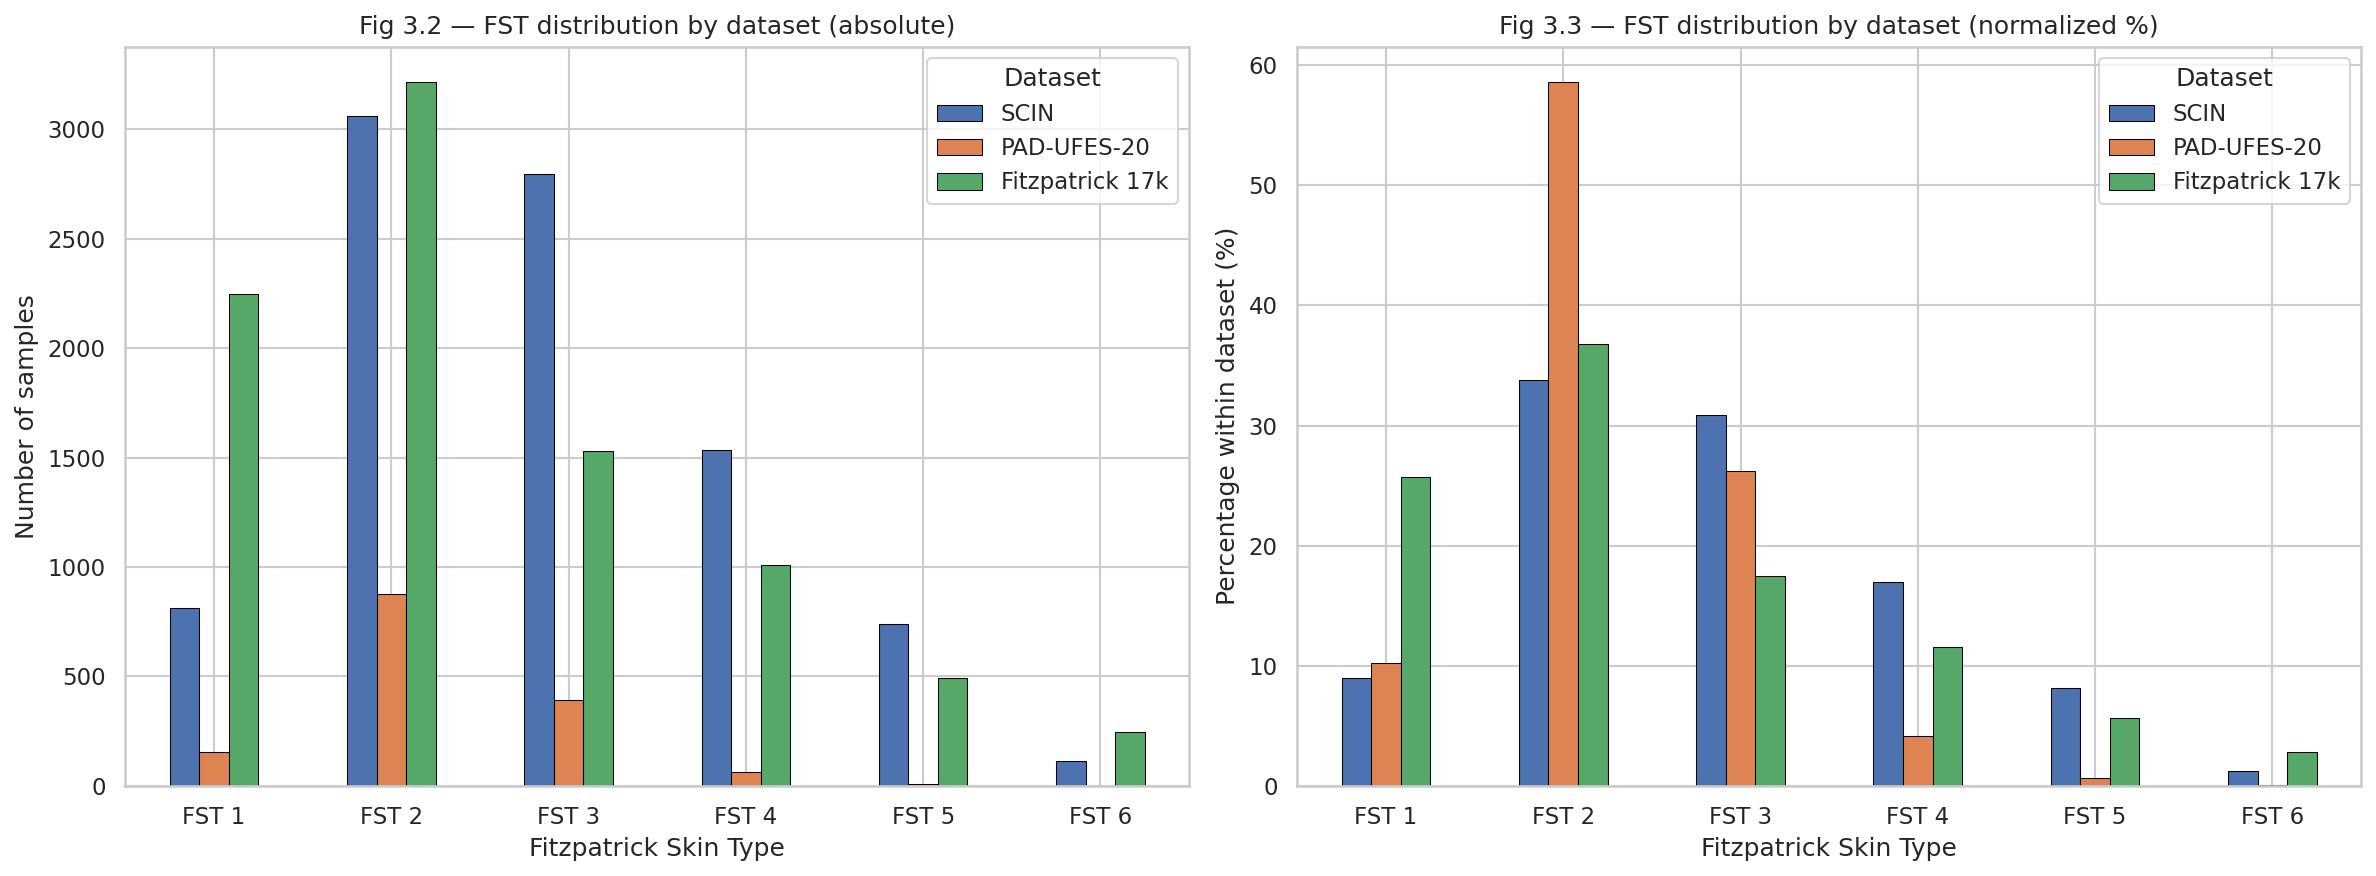

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct = pd.crosstab(df["fitzpatrick_skin_type"], df["source"])
ct = ct[[s for s in SOURCE_KEYS if s in ct.columns]]
ct.rename(columns=DATASET_LABELS, inplace=True)
ct.index = [FST_LABELS[i] for i in ct.index]
ct.plot(kind="bar", ax=axes[0], color=[DATASET_COLORS[k] for k in SOURCE_KEYS], edgecolor="black", linewidth=0.5)
axes[0].set_title("Fig 3.2 \u2014 FST distribution by dataset (absolute)")
axes[0].set_ylabel("Number of samples")
axes[0].set_xlabel("Fitzpatrick Skin Type")
axes[0].legend(title="Dataset")
axes[0].tick_params(axis="x", rotation=0)

ct_norm = pd.crosstab(df["fitzpatrick_skin_type"], df["source"], normalize="columns") * 100
ct_norm = ct_norm[[s for s in SOURCE_KEYS if s in ct_norm.columns]]
ct_norm.rename(columns=DATASET_LABELS, inplace=True)
ct_norm.index = [FST_LABELS[i] for i in ct_norm.index]
ct_norm.plot(kind="bar", ax=axes[1], color=[DATASET_COLORS[k] for k in SOURCE_KEYS], edgecolor="black", linewidth=0.5)
axes[1].set_title("Fig 3.3 \u2014 FST distribution by dataset (normalized %)")
axes[1].set_ylabel("Percentage within dataset (%)")
axes[1].set_xlabel("Fitzpatrick Skin Type")
axes[1].legend(title="Dataset")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_3_2_3_fst_by_dataset.png")
plt.show()

In [9]:
fst_table = pd.crosstab(df["fitzpatrick_skin_type"], df["source"], margins=True, margins_name="Total")
fst_table = fst_table[[s for s in SOURCE_KEYS if s in fst_table.columns] + ["Total"]]
fst_table.rename(columns=DATASET_LABELS, index={i: FST_LABELS[i] for i in range(1, 7)}, inplace=True)

for col in list(fst_table.columns):
    col_total = fst_table.loc["Total", col]
    fst_table[f"{col} (%)"] = (fst_table[col] / col_total * 100).round(1)

display(fst_table)

source,SCIN,PAD-UFES-20,Fitzpatrick 17k,Total,SCIN (%),PAD-UFES-20 (%),Fitzpatrick 17k (%),Total (%)
fitzpatrick_skin_type,,,,,,,,
FST 1,813,153,2247,3213,9.0,10.2,25.7,16.7
FST 2,3061,876,3218,7155,33.8,58.6,36.8,37.1
FST 3,2794,392,1530,4716,30.8,26.2,17.5,24.4
FST 4,1535,62,1009,2606,16.9,4.1,11.5,13.5
FST 5,741,10,491,1242,8.2,0.7,5.6,6.4
FST 6,113,1,245,359,1.2,0.1,2.8,1.9
Total,9057,1494,8740,19291,100.0,100.0,100.0,100.0


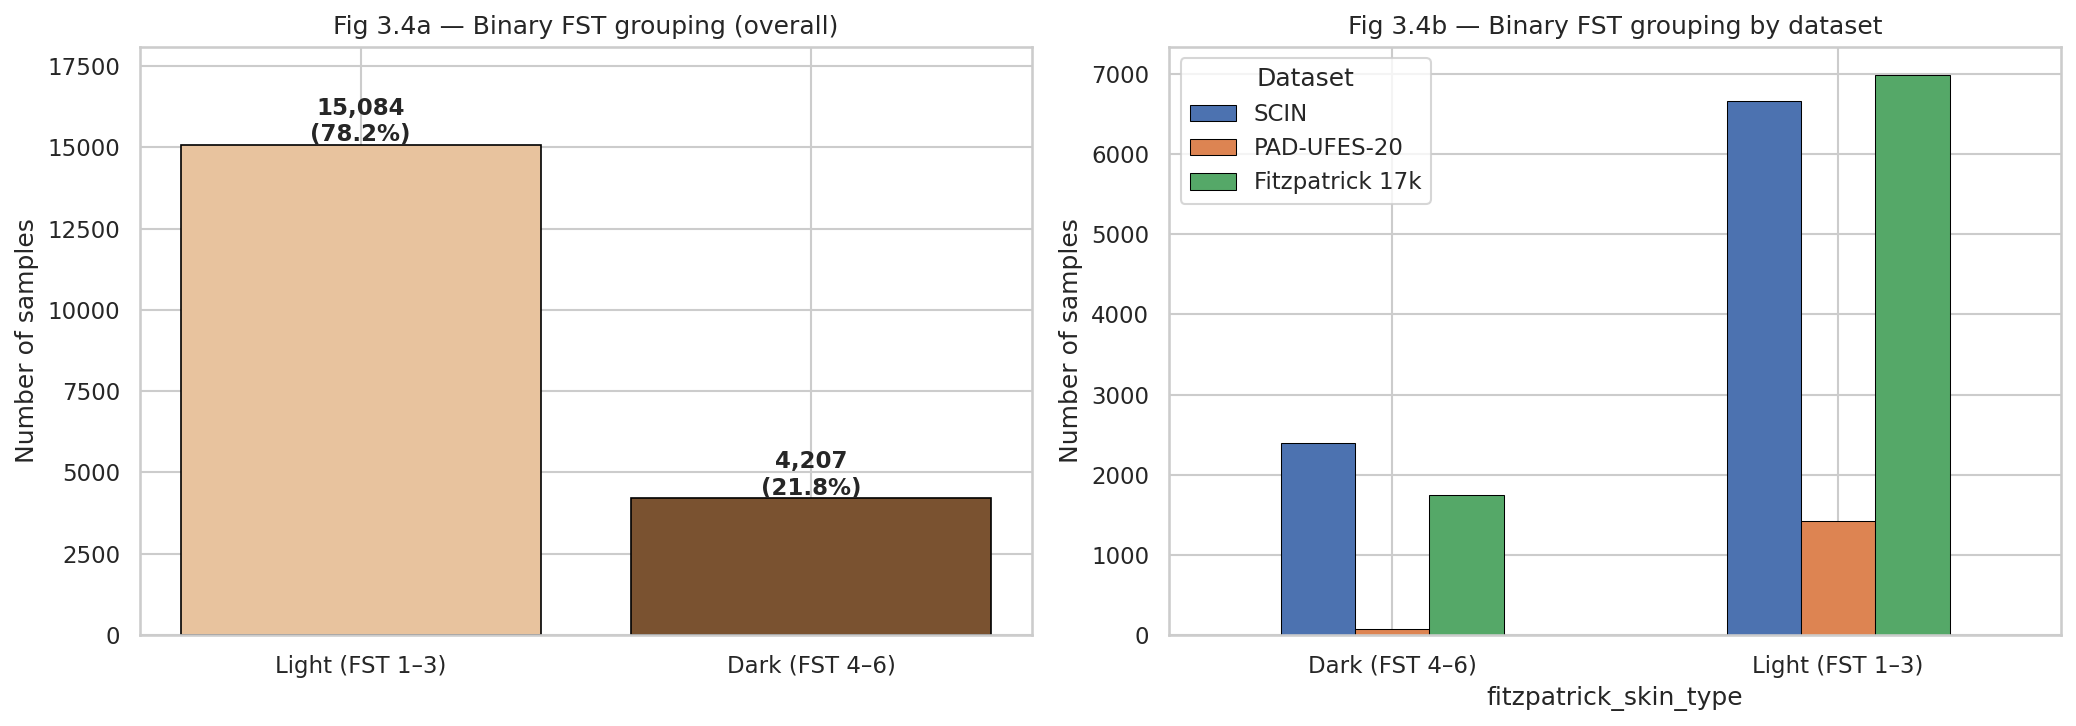

In [10]:
fst_group = df["fitzpatrick_skin_type"].apply(lambda x: "Light (FST 1\u20133)" if x <= 3 else "Dark (FST 4\u20136)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_counts = fst_group.value_counts()
axes[0].bar(group_counts.index, group_counts.values, color=["#E8C39E", "#7A5230"], edgecolor="black", linewidth=0.8)
for i, (label, count) in enumerate(group_counts.items()):
    axes[0].text(
        i, count + 100, f"{count:,}\n({count / len(df) * 100:.1f}%)", ha="center", fontsize=11, fontweight="bold"
    )
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Fig 3.4a \u2014 Binary FST grouping (overall)")
axes[0].set_ylim(0, group_counts.max() * 1.2)

ct_binary = pd.crosstab(fst_group, df["source"])
ct_binary = ct_binary[[s for s in SOURCE_KEYS if s in ct_binary.columns]]
ct_binary.rename(columns=DATASET_LABELS, inplace=True)
ct_binary.plot(kind="bar", ax=axes[1], color=[DATASET_COLORS[k] for k in SOURCE_KEYS], edgecolor="black", linewidth=0.5)
axes[1].set_title("Fig 3.4b \u2014 Binary FST grouping by dataset")
axes[1].set_ylabel("Number of samples")
axes[1].legend(title="Dataset")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_3_4_binary_fst.png")
plt.show()

## 4. Demographic Analysis

Understanding the demographic composition of each dataset is crucial for assessing potential biases. Note that **Fitzpatrick 17k** provides **no age or sex information**, and SCIN has many unknown/unspecified entries. These gaps have important implications for model fairness evaluation.

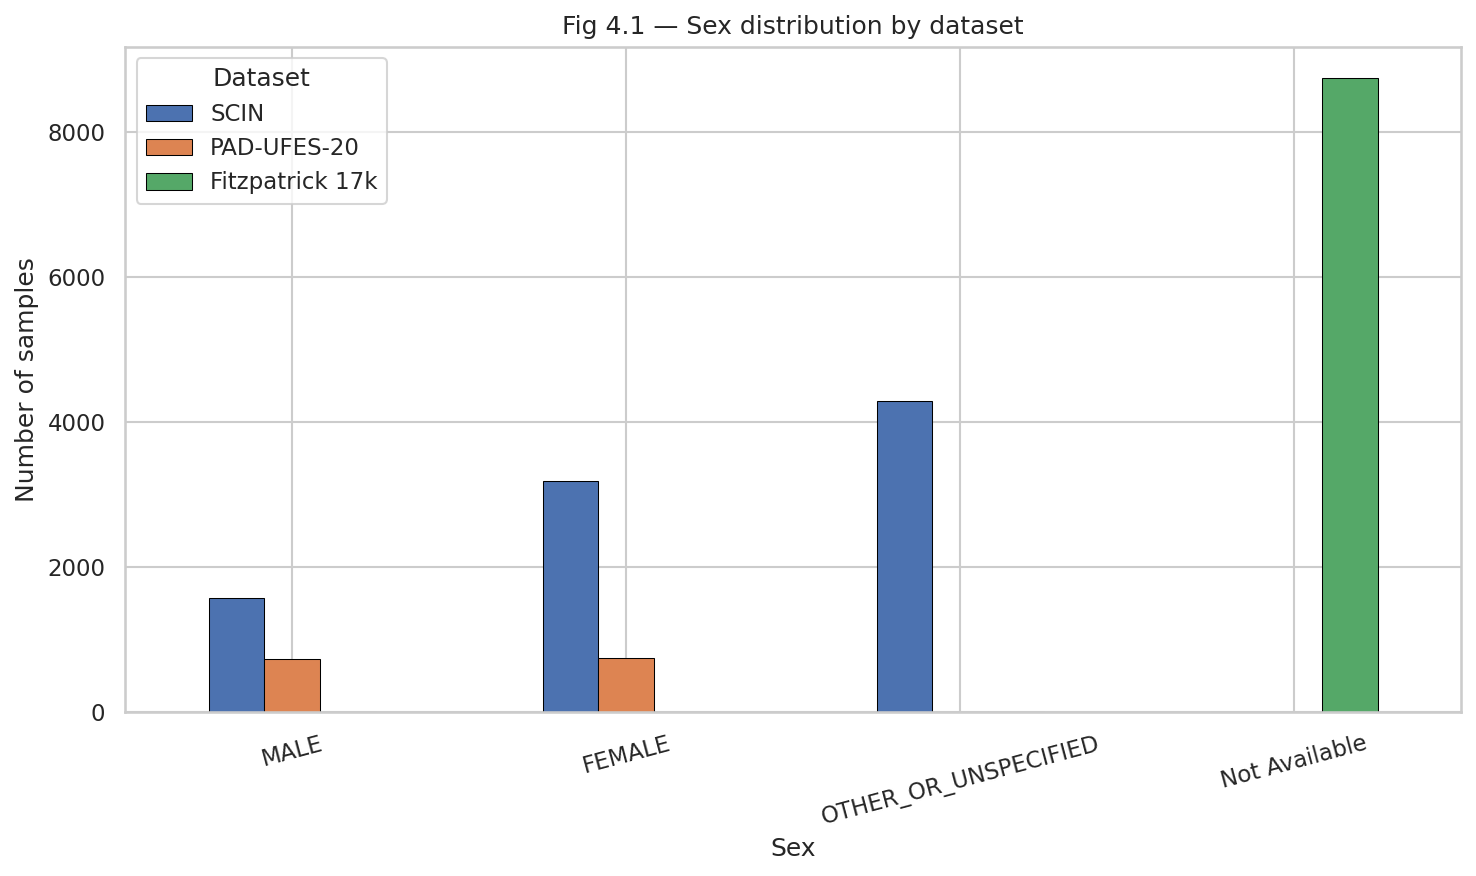

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sex_by_source = pd.crosstab(df["sex"].fillna("Not Available"), df["source"])
sex_by_source = sex_by_source[[s for s in SOURCE_KEYS if s in sex_by_source.columns]]
sex_by_source.rename(columns=DATASET_LABELS, inplace=True)

sex_order = [s for s in ["MALE", "FEMALE", "OTHER_OR_UNSPECIFIED", "Not Available"] if s in sex_by_source.index]
sex_by_source = sex_by_source.loc[sex_order]

sex_by_source.plot(kind="bar", ax=ax, color=[DATASET_COLORS[k] for k in SOURCE_KEYS], edgecolor="black", linewidth=0.5)
ax.set_title("Fig 4.1 \u2014 Sex distribution by dataset")
ax.set_ylabel("Number of samples")
ax.set_xlabel("Sex")
ax.legend(title="Dataset")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_4_1_sex_distribution.png")
plt.show()

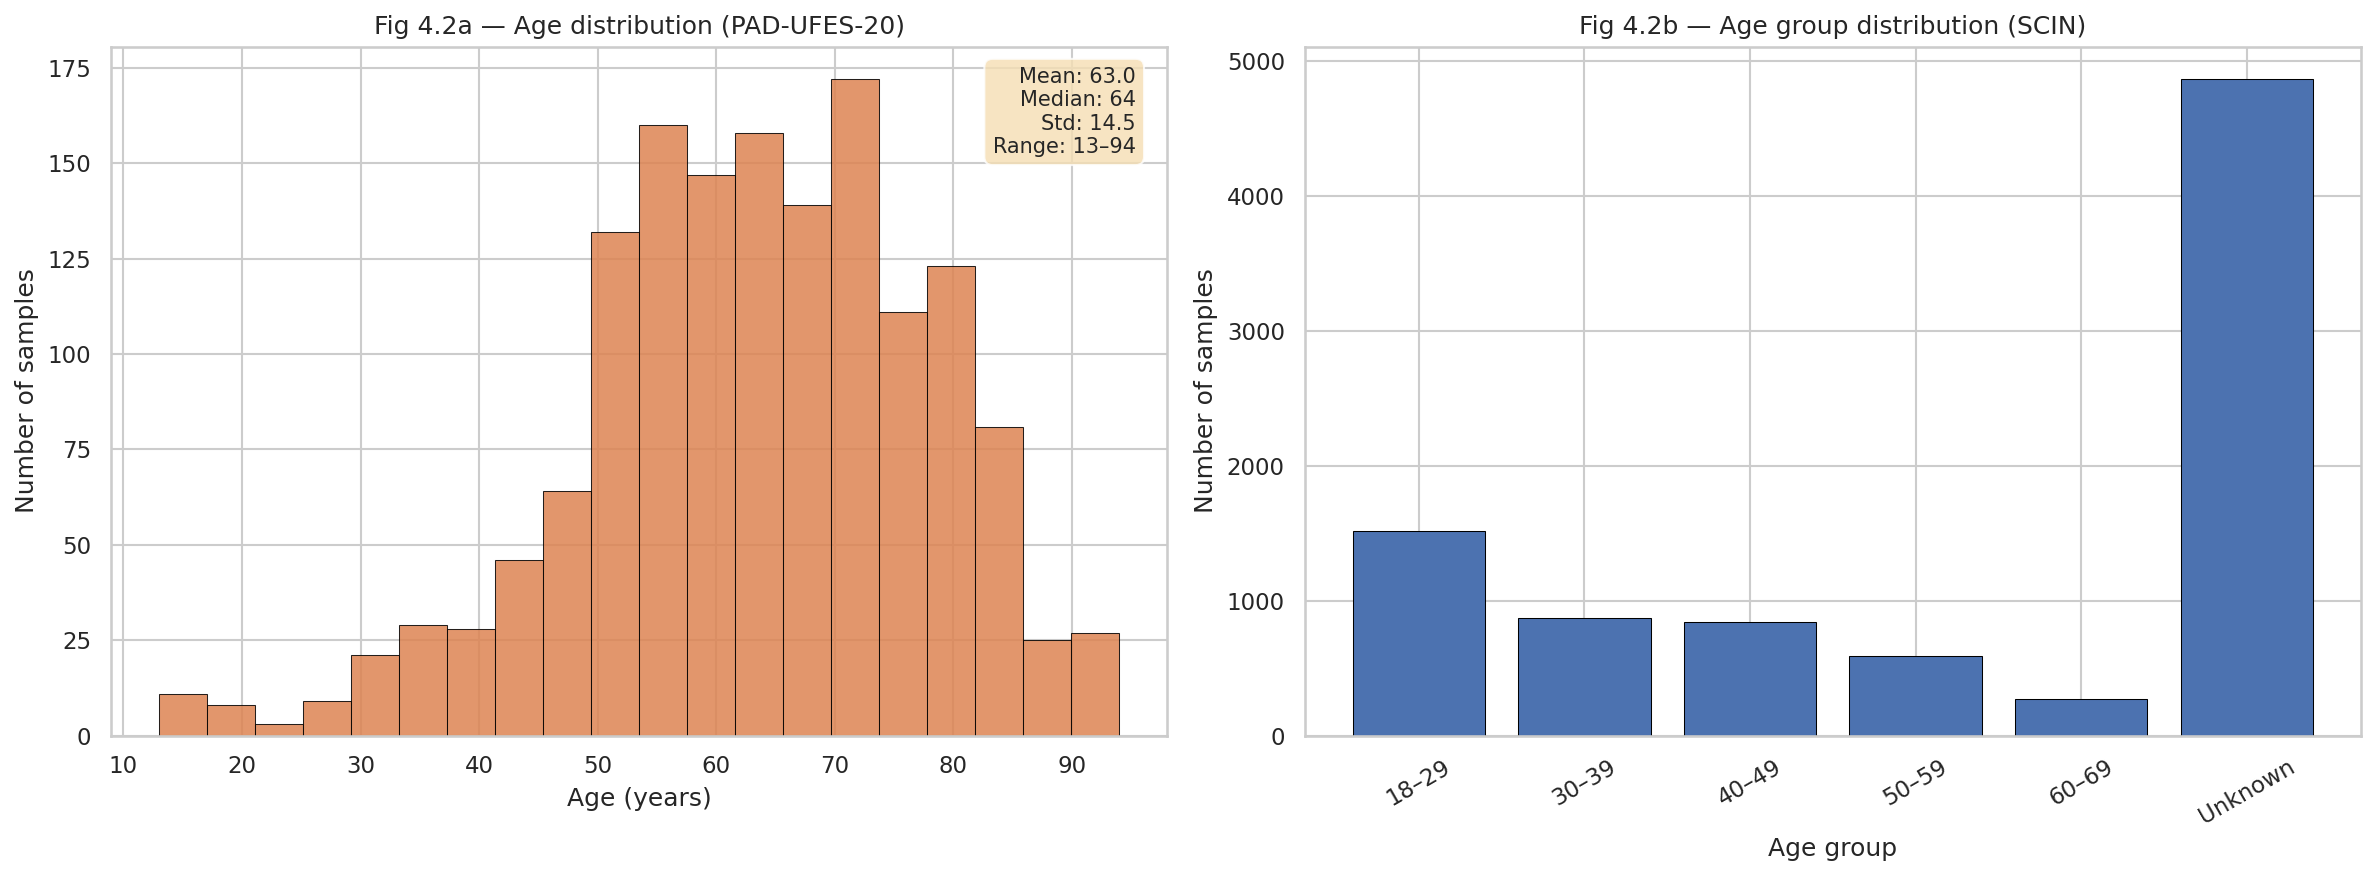

Note: Fitzpatrick 17k has NO age information available.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_pad_unified = df[df["source"] == "pad_ufes"].copy()
df_pad_unified["age_numeric"] = pd.to_numeric(df_pad_unified["age"], errors="coerce")
axes[0].hist(
    df_pad_unified["age_numeric"].dropna(),
    bins=20,
    color=DATASET_COLORS["pad_ufes"],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
)
axes[0].set_title("Fig 4.2a \u2014 Age distribution (PAD-UFES-20)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of samples")
age_stats = df_pad_unified["age_numeric"].describe()
textstr = f"Mean: {age_stats['mean']:.1f}\nMedian: {age_stats['50%']:.0f}\nStd: {age_stats['std']:.1f}\nRange: {age_stats['min']:.0f}\u2013{age_stats['max']:.0f}"
axes[0].text(
    0.97,
    0.97,
    textstr,
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.8),
)

df_scin_unified = df[df["source"] == "scin"].copy()
age_counts = df_scin_unified["age"].value_counts()
age_order = [
    a
    for a in [
        "AGE_18_TO_29",
        "AGE_30_TO_39",
        "AGE_40_TO_49",
        "AGE_50_TO_59",
        "AGE_60_TO_69",
        "AGE_70_PLUS",
        "AGE_UNKNOWN",
    ]
    if a in age_counts.index
]
age_counts = age_counts.reindex(age_order)
age_labels_map = {
    "AGE_18_TO_29": "18\u201329",
    "AGE_30_TO_39": "30\u201339",
    "AGE_40_TO_49": "40\u201349",
    "AGE_50_TO_59": "50\u201359",
    "AGE_60_TO_69": "60\u201369",
    "AGE_70_PLUS": "70+",
    "AGE_UNKNOWN": "Unknown",
}
axes[1].bar(
    [age_labels_map.get(a, a) for a in age_counts.index],
    age_counts.values,
    color=DATASET_COLORS["scin"],
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_title("Fig 4.2b \u2014 Age group distribution (SCIN)")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Number of samples")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_4_2_age_distribution.png")
plt.show()
print("Note: Fitzpatrick 17k has NO age information available.")

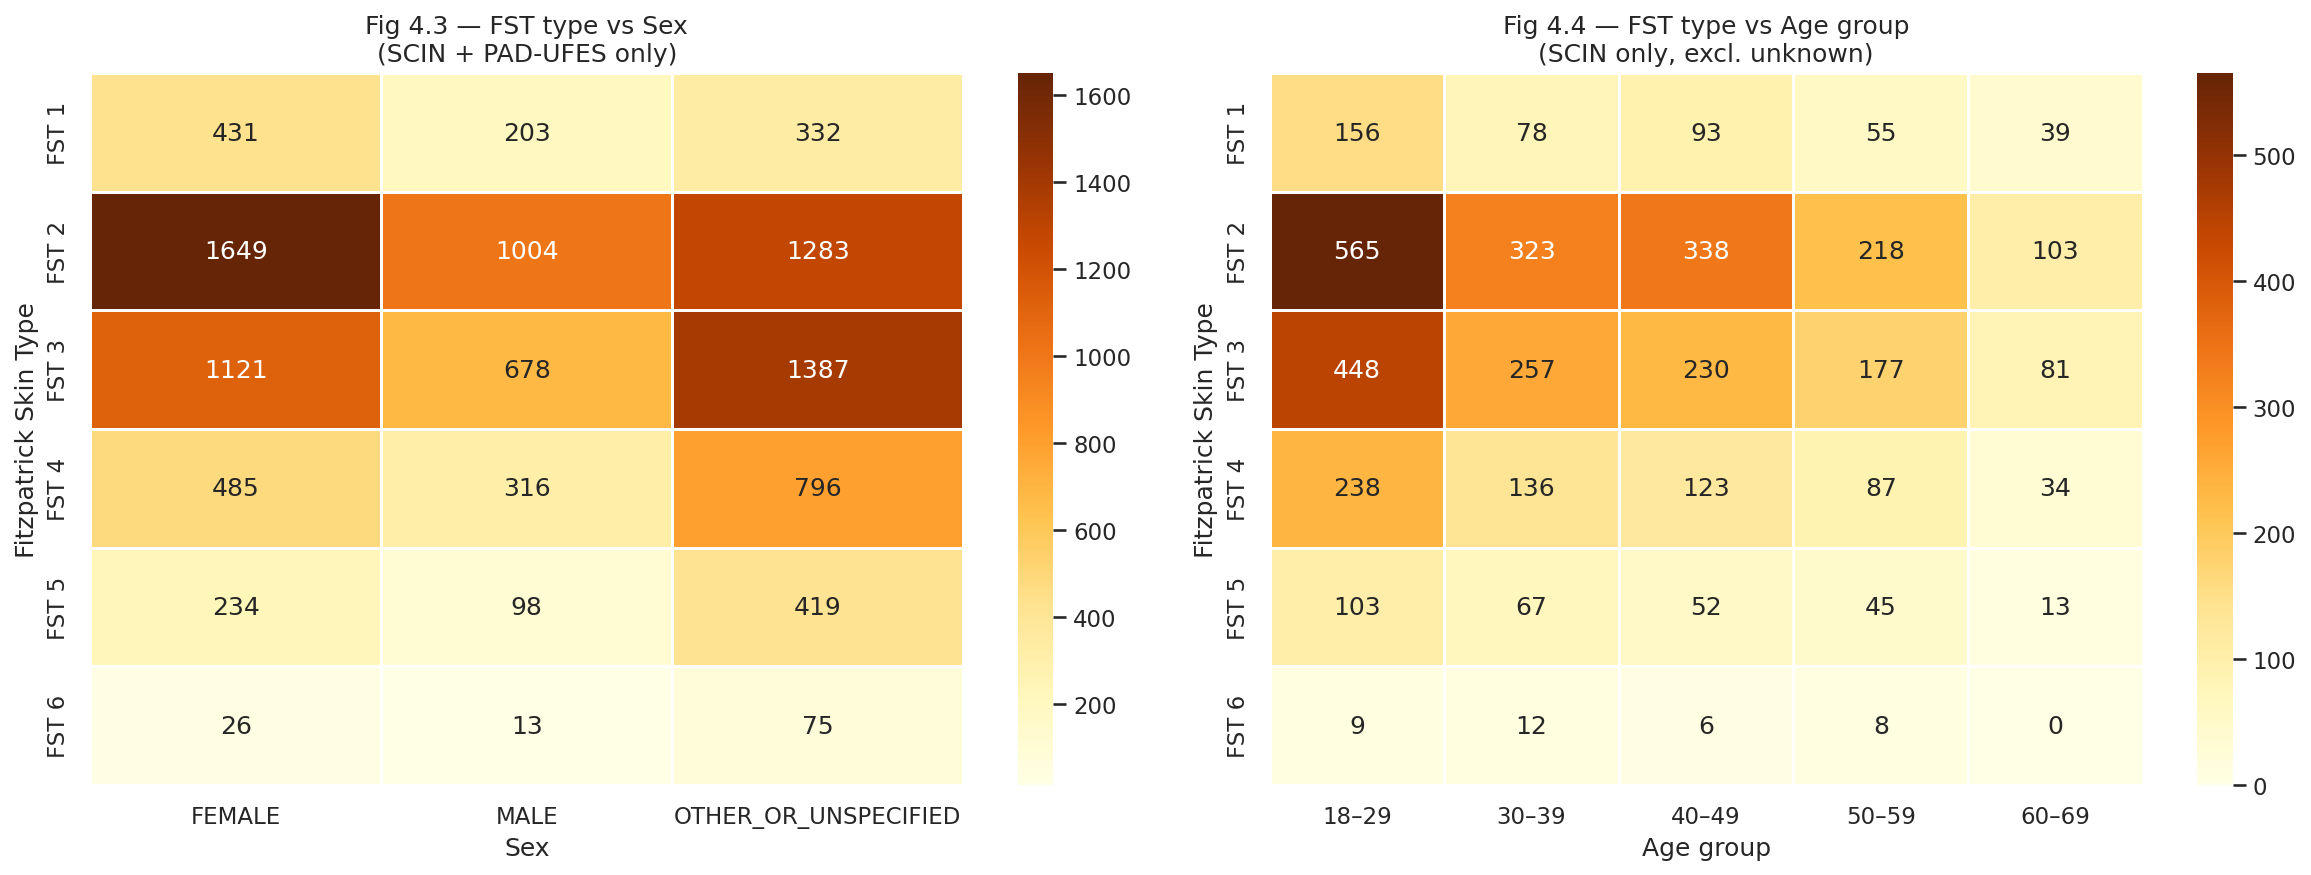

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_with_sex = df[df["sex"].notna() & (df["sex"] != "Not Available")].copy()
ct_fst_sex = pd.crosstab(df_with_sex["fitzpatrick_skin_type"], df_with_sex["sex"])
ct_fst_sex.index = [FST_LABELS.get(i, i) for i in ct_fst_sex.index]
sns.heatmap(ct_fst_sex, annot=True, fmt="d", cmap="YlOrBr", ax=axes[0], linewidths=0.5, linecolor="white")
axes[0].set_title("Fig 4.3 \u2014 FST type vs Sex\n(SCIN + PAD-UFES only)")
axes[0].set_ylabel("Fitzpatrick Skin Type")
axes[0].set_xlabel("Sex")

df_scin_with_age = df_scin_unified[df_scin_unified["age"] != "AGE_UNKNOWN"].copy()
ct_fst_age = pd.crosstab(df_scin_with_age["fitzpatrick_skin_type"], df_scin_with_age["age"])
age_col_order = [a for a in age_order if a in ct_fst_age.columns and a != "AGE_UNKNOWN"]
ct_fst_age = ct_fst_age[age_col_order]
ct_fst_age.columns = [age_labels_map.get(c, c) for c in ct_fst_age.columns]
ct_fst_age.index = [FST_LABELS.get(i, i) for i in ct_fst_age.index]
sns.heatmap(ct_fst_age, annot=True, fmt="d", cmap="YlOrBr", ax=axes[1], linewidths=0.5, linecolor="white")
axes[1].set_title("Fig 4.4 \u2014 FST type vs Age group\n(SCIN only, excl. unknown)")
axes[1].set_ylabel("Fitzpatrick Skin Type")
axes[1].set_xlabel("Age group")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_4_3_4_fst_demographics.png")
plt.show()

## 5. Diagnosis / Condition Analysis

While the primary task is FST classification, understanding the underlying medical conditions is important context. The three datasets use different diagnosis formats:

- **SCIN:** Weighted probability distributions over multiple possible diagnoses
- **PAD-UFES-20:** Single definitive diagnoses (6 skin lesion types, all biopsy-confirmed)
- **Fitzpatrick 17k:** Hierarchical labeling with 3-class and 9-class groupings

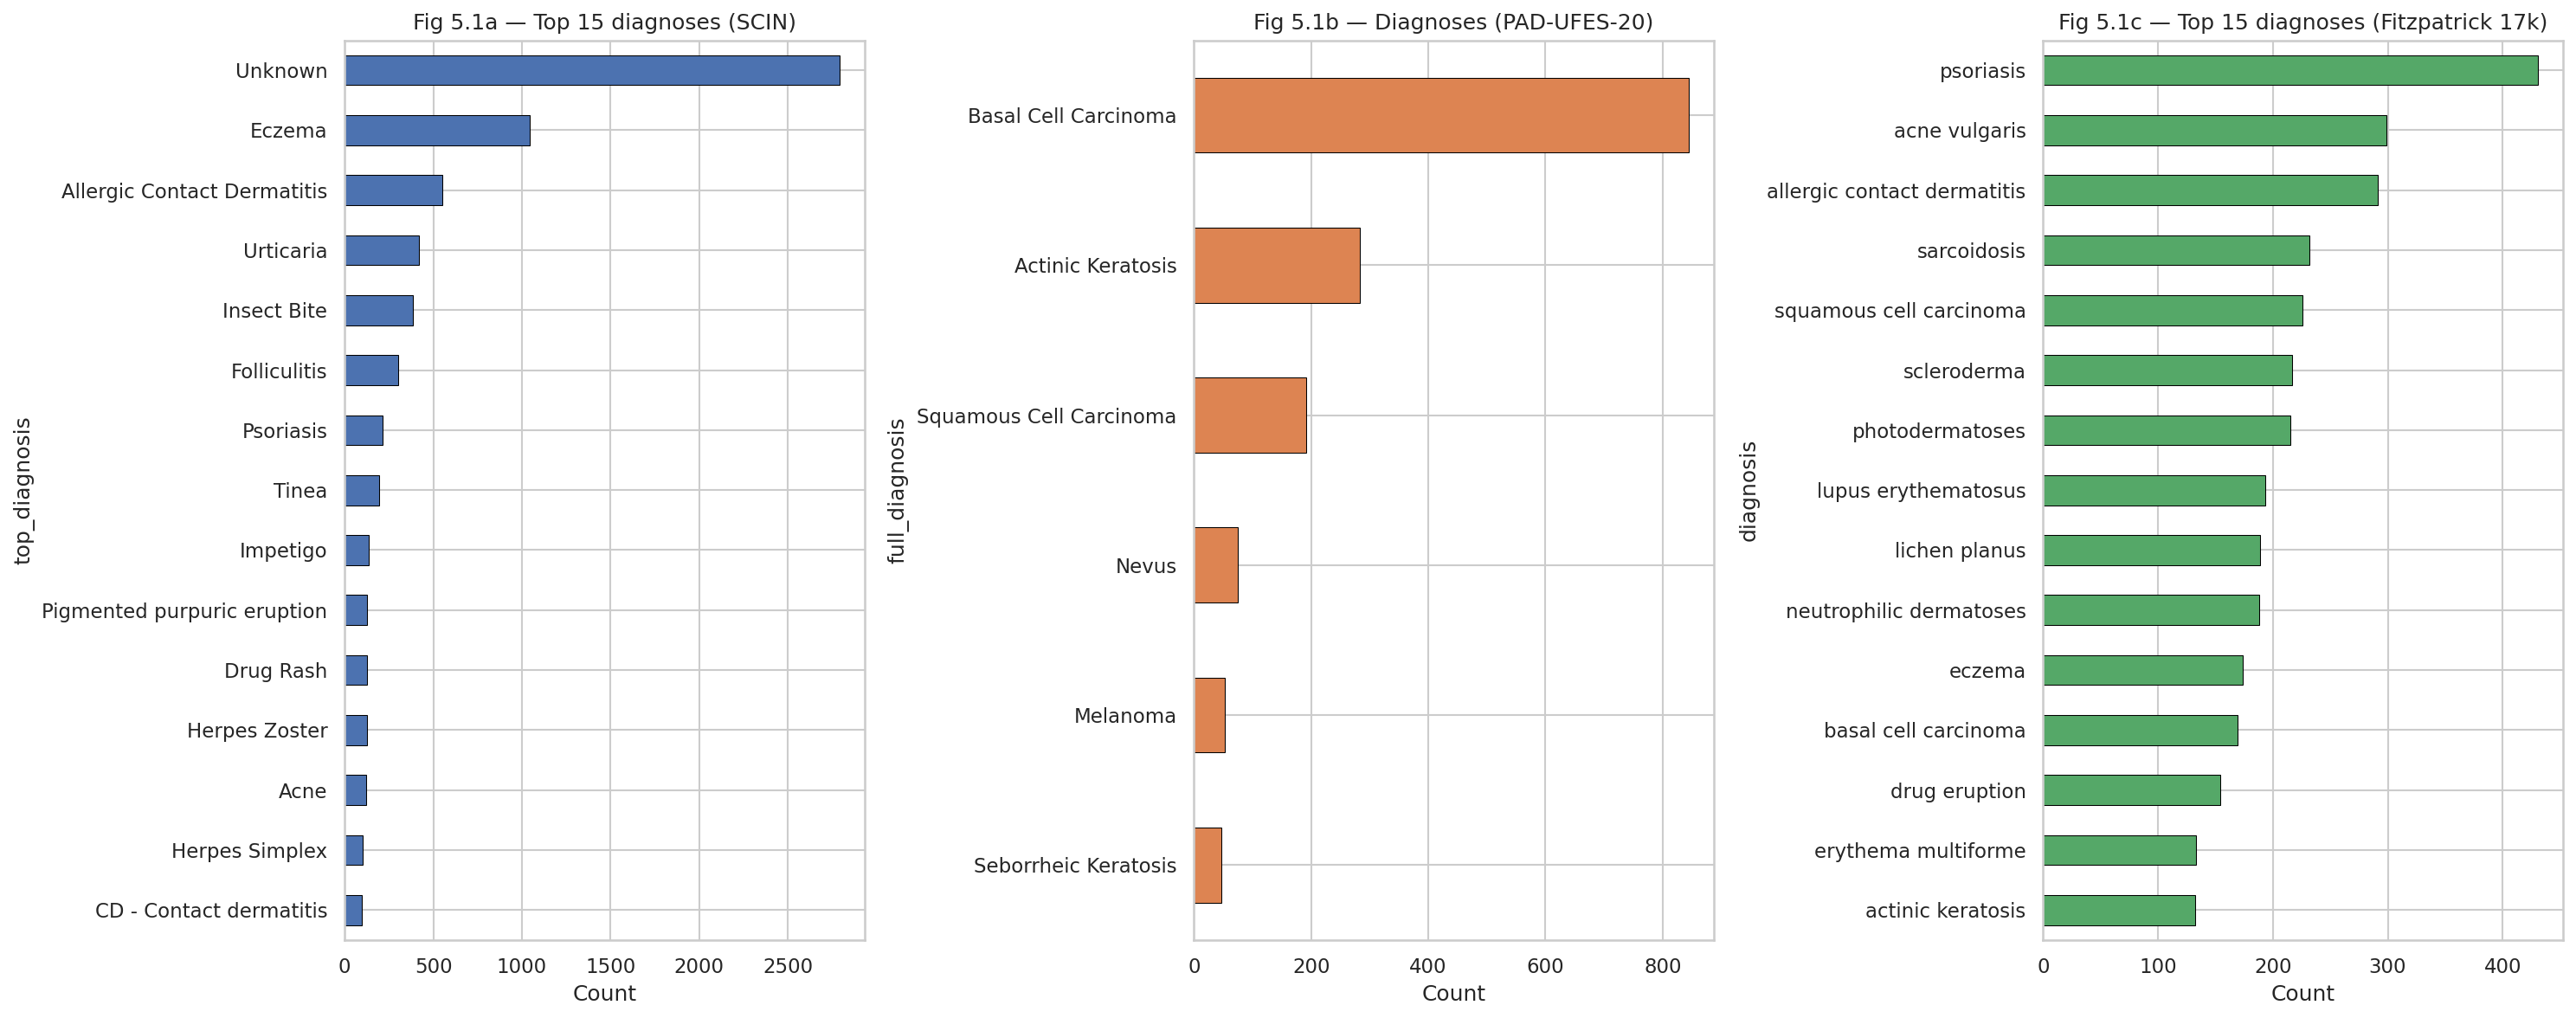

Unique diagnoses — SCIN: 201, PAD-UFES: 6, Fitzpatrick 17k: 114


In [14]:
df_scin_diag = df[df["source"] == "scin"].copy()


def extract_top_diagnosis(diag_str):
    try:
        d = ast.literal_eval(diag_str)
        return max(d, key=d.get) if d else "Unknown"
    except (ValueError, SyntaxError):
        return "Unknown"


df_scin_diag["top_diagnosis"] = df_scin_diag["diagnosis"].apply(extract_top_diagnosis)

PAD_DIAG_MAP = {
    "BCC": "Basal Cell Carcinoma",
    "SCC": "Squamous Cell Carcinoma",
    "ACK": "Actinic Keratosis",
    "SEK": "Seborrheic Keratosis",
    "NEV": "Nevus",
    "MEL": "Melanoma",
}
df_pad_diag = df[df["source"] == "pad_ufes"].copy()
df_pad_diag["full_diagnosis"] = df_pad_diag["diagnosis"].map(PAD_DIAG_MAP)

df_fitz_diag = df[df["source"] == "fitzpatrick_17k"].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
top_n = 15

df_scin_diag["top_diagnosis"].value_counts().head(top_n).sort_values().plot(
    kind="barh", ax=axes[0], color=DATASET_COLORS["scin"], edgecolor="black", linewidth=0.5
)
axes[0].set_title(f"Fig 5.1a \u2014 Top {top_n} diagnoses (SCIN)")
axes[0].set_xlabel("Count")

df_pad_diag["full_diagnosis"].value_counts().sort_values().plot(
    kind="barh", ax=axes[1], color=DATASET_COLORS["pad_ufes"], edgecolor="black", linewidth=0.5
)
axes[1].set_title("Fig 5.1b \u2014 Diagnoses (PAD-UFES-20)")
axes[1].set_xlabel("Count")

df_fitz_diag["diagnosis"].value_counts().head(top_n).sort_values().plot(
    kind="barh", ax=axes[2], color=DATASET_COLORS["fitzpatrick_17k"], edgecolor="black", linewidth=0.5
)
axes[2].set_title(f"Fig 5.1c \u2014 Top {top_n} diagnoses (Fitzpatrick 17k)")
axes[2].set_xlabel("Count")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_5_1_top_diagnoses.png")
plt.show()

print(
    f"Unique diagnoses \u2014 SCIN: {df_scin_diag['top_diagnosis'].nunique()}, PAD-UFES: {df_pad_diag['full_diagnosis'].nunique()}, Fitzpatrick 17k: {df_fitz_diag['diagnosis'].nunique()}"
)

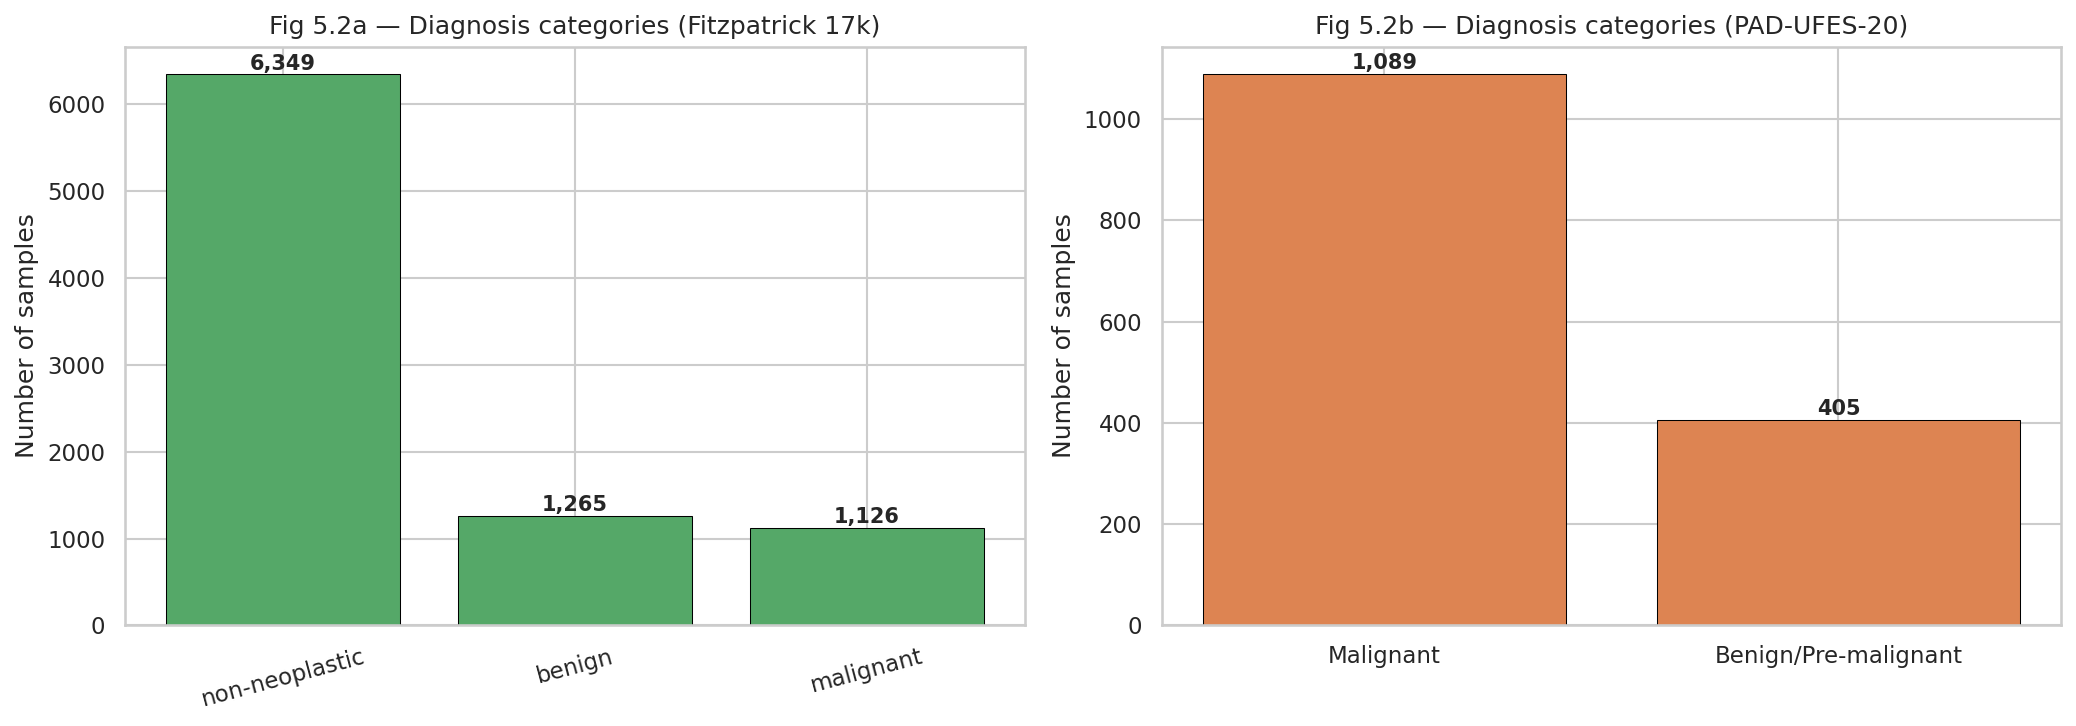

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fitz_3class = df_fitz["three_partition_label"].value_counts()
axes[0].bar(
    fitz_3class.index, fitz_3class.values, color=DATASET_COLORS["fitzpatrick_17k"], edgecolor="black", linewidth=0.5
)
for i, (label, count) in enumerate(fitz_3class.items()):
    axes[0].text(i, count + 50, f"{count:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Fig 5.2a \u2014 Diagnosis categories (Fitzpatrick 17k)")
axes[0].set_ylabel("Number of samples")
axes[0].tick_params(axis="x", rotation=15)

malignant_codes = {"BCC", "SCC", "MEL"}
pad_category = df_pad_diag["diagnosis"].apply(lambda x: "Malignant" if x in malignant_codes else "Benign/Pre-malignant")
pad_cat = pad_category.value_counts()
axes[1].bar(pad_cat.index, pad_cat.values, color=DATASET_COLORS["pad_ufes"], edgecolor="black", linewidth=0.5)
for i, (label, count) in enumerate(pad_cat.items()):
    axes[1].text(i, count + 10, f"{count:,}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Fig 5.2b \u2014 Diagnosis categories (PAD-UFES-20)")
axes[1].set_ylabel("Number of samples")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_5_2_diagnosis_categories.png")
plt.show()

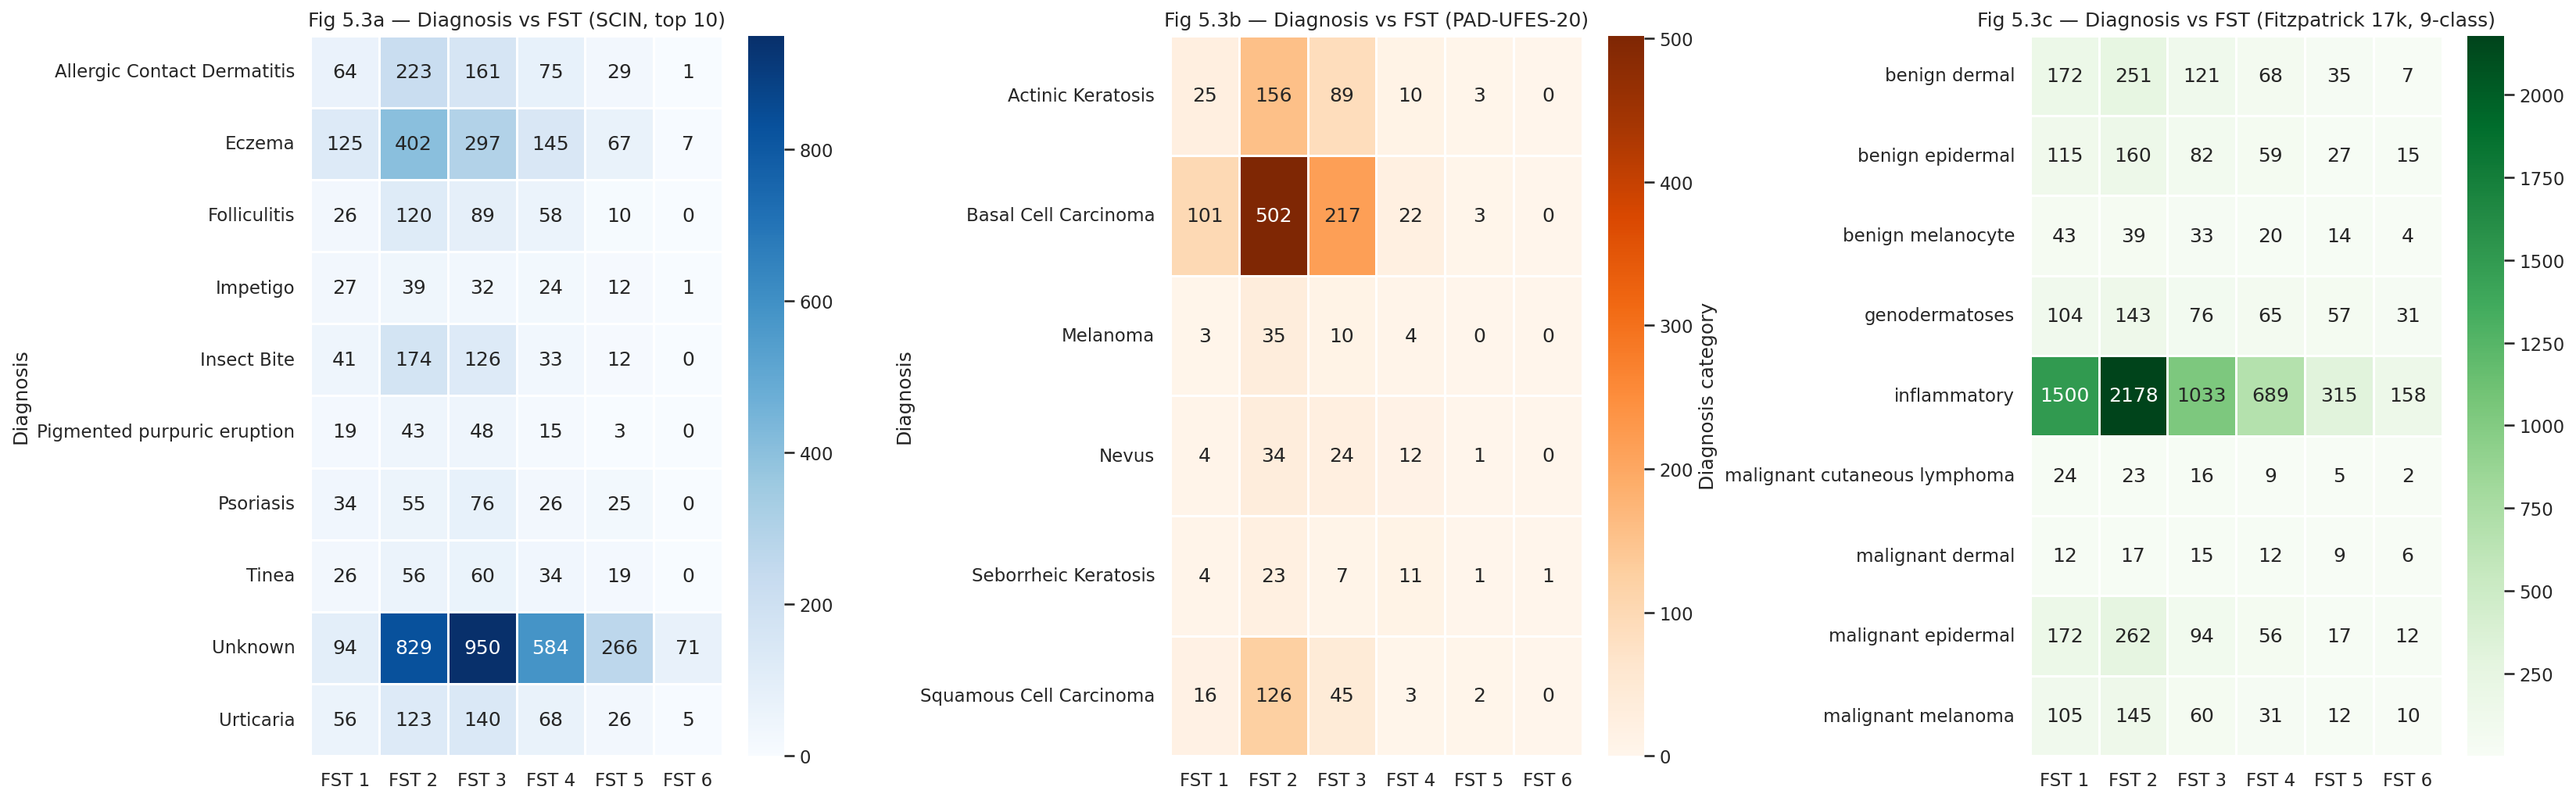

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

scin_top10 = df_scin_diag["top_diagnosis"].value_counts().head(10).index
df_scin_top10 = df_scin_diag[df_scin_diag["top_diagnosis"].isin(scin_top10)]
ct_scin = pd.crosstab(df_scin_top10["top_diagnosis"], df_scin_top10["fitzpatrick_skin_type"])
ct_scin.columns = [FST_LABELS.get(c, c) for c in ct_scin.columns]
sns.heatmap(ct_scin, annot=True, fmt="d", cmap="Blues", ax=axes[0], linewidths=0.5, linecolor="white")
axes[0].set_title("Fig 5.3a \u2014 Diagnosis vs FST (SCIN, top 10)")
axes[0].set_ylabel("Diagnosis")

ct_pad = pd.crosstab(df_pad_diag["full_diagnosis"], df_pad_diag["fitzpatrick_skin_type"])
ct_pad.columns = [FST_LABELS.get(c, c) for c in ct_pad.columns]
sns.heatmap(ct_pad, annot=True, fmt="d", cmap="Oranges", ax=axes[1], linewidths=0.5, linecolor="white")
axes[1].set_title("Fig 5.3b \u2014 Diagnosis vs FST (PAD-UFES-20)")
axes[1].set_ylabel("Diagnosis")

ct_fitz = pd.crosstab(df_fitz["nine_partition_label"], df_fitz["fitzpatrick"])
ct_fitz.columns = [FST_LABELS.get(c, c) for c in ct_fitz.columns]
sns.heatmap(ct_fitz, annot=True, fmt="d", cmap="Greens", ax=axes[2], linewidths=0.5, linecolor="white")
axes[2].set_title("Fig 5.3c \u2014 Diagnosis vs FST (Fitzpatrick 17k, 9-class)")
axes[2].set_ylabel("Diagnosis category")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_5_3_diagnosis_vs_fst.png")
plt.show()

## 6. Image Properties Analysis (Pixel-Level)

This section loads every image to compute resolution, aspect ratio, and color channel statistics. These properties are critical for determining preprocessing requirements (resizing, normalization, augmentation).

In [ ]:
def compute_image_stats(image_path):
    try:
        img = Image.open(image_path)
        width, height = img.size
        stat = ImageStat.Stat(img.convert("RGB"))
        return {
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "mean_r": stat.mean[0],
            "mean_g": stat.mean[1],
            "mean_b": stat.mean[2],
            "std_r": stat.stddev[0],
            "std_g": stat.stddev[1],
            "std_b": stat.stddev[2],
            "brightness": np.mean(stat.mean),
        }
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None


records = []
total = len(df)
print(f"Processing {total:,} images...")

for idx, row in df.iterrows():
    img_path = DATA_DIR / row["image_path"]
    stats = compute_image_stats(img_path)
    if stats is not None:
        stats["source"] = row["source"]
        stats["fitzpatrick_skin_type"] = row["fitzpatrick_skin_type"]
        records.append(stats)
    if (idx + 1) % 5000 == 0:
        print(f"  Processed {idx + 1:,}/{total:,} images...")

df_img = pd.DataFrame(records)
print(f"\nSuccessfully processed {len(df_img):,}/{total:,} images.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for source_key, label in DATASET_LABELS.items():
    mask = df_img["source"] == source_key
    axes[0].scatter(
        df_img.loc[mask, "width"],
        df_img.loc[mask, "height"],
        alpha=0.3,
        s=10,
        label=label,
        color=DATASET_COLORS[source_key],
    )
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Height (pixels)")
axes[0].set_title("Fig 6.1 \u2014 Image resolution (width vs height)")
axes[0].legend()

df_img_melted = pd.melt(
    df_img[["source", "width", "height"]],
    id_vars=["source"],
    value_vars=["width", "height"],
    var_name="Dimension",
    value_name="Pixels",
)
df_img_melted["Dataset"] = df_img_melted["source"].map(DATASET_LABELS)
sns.boxplot(data=df_img_melted, x="Dataset", y="Pixels", hue="Dimension", ax=axes[1], palette="Set2")
axes[1].set_title("Fig 6.2 \u2014 Resolution distributions by dataset")
axes[1].set_ylabel("Pixels")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_6_1_2_resolution.png")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for source_key, label in DATASET_LABELS.items():
    mask = df_img["source"] == source_key
    ax.hist(
        df_img.loc[mask, "aspect_ratio"],
        bins=50,
        alpha=0.6,
        label=label,
        color=DATASET_COLORS[source_key],
        edgecolor="black",
        linewidth=0.3,
    )

ax.axvline(x=1.0, color="red", linestyle="--", alpha=0.5, label="Square (1:1)")
ax.set_xlabel("Aspect ratio (width / height)")
ax.set_ylabel("Count")
ax.set_title("Fig 6.3 \u2014 Aspect ratio distribution by dataset")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_6_3_aspect_ratio.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

channels = ["r", "g", "b"]
channel_names = ["Red", "Green", "Blue"]

for i, (ch, ch_name) in enumerate(zip(channels, channel_names)):
    for source_key, label in DATASET_LABELS.items():
        mask = df_img["source"] == source_key
        sns.kdeplot(
            df_img.loc[mask, f"mean_{ch}"], ax=axes[0, i], label=label, color=DATASET_COLORS[source_key], linewidth=2
        )
    axes[0, i].set_title(f"Fig 6.4 \u2014 {ch_name} channel mean")
    axes[0, i].set_xlabel("Mean intensity (0\u2013255)")
    axes[0, i].legend()

    for source_key, label in DATASET_LABELS.items():
        mask = df_img["source"] == source_key
        sns.kdeplot(
            df_img.loc[mask, f"std_{ch}"], ax=axes[1, i], label=label, color=DATASET_COLORS[source_key], linewidth=2
        )
    axes[1, i].set_title(f"Fig 6.5 \u2014 {ch_name} channel std dev")
    axes[1, i].set_xlabel("Std deviation")
    axes[1, i].legend()

plt.suptitle("Color channel intensity distributions by dataset", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_6_4_5_color_channels.png")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for source_key, label in DATASET_LABELS.items():
    mask = df_img["source"] == source_key
    sns.kdeplot(
        df_img.loc[mask, "brightness"],
        ax=ax,
        label=label,
        color=DATASET_COLORS[source_key],
        linewidth=2,
        fill=True,
        alpha=0.15,
    )

ax.set_xlabel("Mean brightness (average of RGB means, 0\u2013255)")
ax.set_ylabel("Density")
ax.set_title("Fig 6.6 \u2014 Brightness distribution by dataset")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_6_6_brightness.png")
plt.show()

In [ ]:
stats_summary = (
    df_img.groupby("source")
    .agg(
        width_min=("width", "min"),
        width_max=("width", "max"),
        width_mean=("width", "mean"),
        width_median=("width", "median"),
        height_min=("height", "min"),
        height_max=("height", "max"),
        height_mean=("height", "mean"),
        height_median=("height", "median"),
        ar_mean=("aspect_ratio", "mean"),
        ar_std=("aspect_ratio", "std"),
        bright_mean=("brightness", "mean"),
        bright_std=("brightness", "std"),
    )
    .round(1)
)
stats_summary.index = stats_summary.index.map(DATASET_LABELS)
display(stats_summary.T)

In [ ]:
fig, axes = plt.subplots(6, 3, figsize=(15, 30))

for col_idx, (source_key, label) in enumerate(DATASET_LABELS.items()):
    df_source = df[df["source"] == source_key]
    for row_idx, fst in enumerate(range(1, 7)):
        ax = axes[row_idx, col_idx]
        candidates = df_source[df_source["fitzpatrick_skin_type"] == fst]
        if len(candidates) > 0:
            sample = candidates.sample(1, random_state=42).iloc[0]
            img_path = DATA_DIR / sample["image_path"]
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(f"{label} \u2014 {FST_LABELS[fst]}", fontsize=10)
            except Exception:
                ax.text(0.5, 0.5, "Load error", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{label} \u2014 {FST_LABELS[fst]}", fontsize=10)
        else:
            ax.text(0.5, 0.5, "No samples", ha="center", va="center", transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_title(f"{label} \u2014 {FST_LABELS[fst]}", fontsize=10)
        ax.axis("off")

plt.suptitle("Fig 6.7 \u2014 Sample images per FST type and dataset", fontsize=16, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_6_7_sample_grid.png")
plt.show()

## 7. Cross-Dataset Comparison & Preprocessing Recommendations

This section synthesizes findings from all previous analyses and provides actionable recommendations for preprocessing and training pipeline design.

In [ ]:
features = df_img[["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b", "brightness", "aspect_ratio"]].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(features_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for source_key, label in DATASET_LABELS.items():
    mask = (df_img["source"] == source_key).values
    axes[0].scatter(
        pca_result[mask, 0], pca_result[mask, 1], alpha=0.2, s=8, label=label, color=DATASET_COLORS[source_key]
    )
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
axes[0].set_title("Fig 7.1a \u2014 PCA of image-level features (by dataset)")
axes[0].legend(markerscale=3)

for fst in range(1, 7):
    mask = (df_img["fitzpatrick_skin_type"] == fst).values
    axes[1].scatter(
        pca_result[mask, 0], pca_result[mask, 1], alpha=0.2, s=8, label=FST_LABELS[fst], color=FST_COLORS[fst]
    )
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
axes[1].set_title("Fig 7.1b \u2014 PCA of image-level features (by FST type)")
axes[1].legend(markerscale=3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_7_1_pca_features.png")
plt.show()

print(
    f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}, Total={sum(pca.explained_variance_ratio_):.3f}"
)

In [ ]:
print("Per-channel mean and std per dataset (for normalization):")
print("(Values in 0-255 scale; divide by 255 for 0-1 scale)\n")
for source_key, label in DATASET_LABELS.items():
    mask = df_img["source"] == source_key
    subset = df_img[mask]
    print(f"{label}:")
    print(f"  R: mean={subset['mean_r'].mean():.2f}, std={subset['std_r'].mean():.2f}")
    print(f"  G: mean={subset['mean_g'].mean():.2f}, std={subset['std_g'].mean():.2f}")
    print(f"  B: mean={subset['mean_b'].mean():.2f}, std={subset['std_b'].mean():.2f}")
    print()

print("Combined dataset:")
print(f"  R: mean={df_img['mean_r'].mean():.2f}, std={df_img['std_r'].mean():.2f}")
print(f"  G: mean={df_img['mean_g'].mean():.2f}, std={df_img['std_g'].mean():.2f}")
print(f"  B: mean={df_img['mean_b'].mean():.2f}, std={df_img['std_b'].mean():.2f}")

### Summary & Preprocessing Recommendations

#### Key Findings

| Property | SCIN | PAD-UFES-20 | Fitzpatrick 17k |
|---|---|---|---|
| Image format | PNG | PNG | JPG |
| FST coverage | 1\u20136 | 1\u20134 | 1 \u20136 |
| Age | Partial (groups) | Yes (integer) | None |
| Sex | Partial | Yes | None |

#### Preprocessing Recommendations

1. **Resizing:** Images vary significantly in resolution across datasets. A uniform target size (e.g., 224\u00d7224 or 256\u00d7256) is required for model input. Consider center-crop or resize-with-padding based on aspect ratio findings.

2. **Normalization:** Given the visible differences in color distributions, per-channel normalization is recommended. Use ImageNet statistics if fine-tuning a pre-trained model, or dataset-specific statistics computed above.

3. **Data Augmentation:** Based on the PCA analysis, if datasets cluster separately, aggressive color augmentation (jitter, random grayscale, random brightness/contrast) can bridge domain gaps.

4. **Class Imbalance:** Use stratified sampling, class-weighted loss, or oversampling of minority FST classes (especially FST 5 and 6 if underrepresented).

5. **Train/Val/Test Split:** Stratify by both FST type AND dataset source to ensure representative splits. Consider also stratifying by diagnosis to avoid data leakage.